## How many languages exist in the world?

I grew up speaking Mandarin Chinese at home and English at school, and I have learned many other languages such as Russian and American Sign Language as a hobby. I've always had an interest in languages around the world and how they relate to each other. If you took a guess on how many languages are currently spoken in the world, you may expect it to be in the hundreds. In reality, there are approximately 7,159 living languages in our globe! If we look at the entire human history, there are approximately 31,000 languages including both present and extinct ones!

### Looking at my data

I retrieved my data from Github on the [Tidy Tuesday's 2025 data page](https://github.com/rfordatascience/tidytuesday/blob/main/data/2025/2025-12-23/readme.md). It includes all of the langauges spoken in the world, the macroarea it is located in, latitude, longitude, langauge ID code, country it is spoken in, whether or not it is an isolate language, and the family id.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

language = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2025/2025-12-23/languages.csv')

language.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8612 entries, 0 to 8611
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            8612 non-null   object 
 1   name          8612 non-null   object 
 2   macroarea     8388 non-null   object 
 3   latitude      8300 non-null   float64
 4   longitude     8300 non-null   float64
 5   iso639p3code  7856 non-null   object 
 6   countries     8510 non-null   object 
 7   is_isolate    8612 non-null   bool   
 8   family_id     8430 non-null   object 
dtypes: bool(1), float64(2), object(6)
memory usage: 546.8+ KB


In [2]:
language = language.drop(columns=['family_id'])

language.head()

,id,name,macroarea,latitude,longitude,iso639p3code,countries,is_isolate
0,fasu1242,Fasu,Papunesia,-6.626870,143.284000,faa,PG,True
1,wash1253,Washo,NaN,38.818400,-119.640000,was,US,True
2,taua1242,Tauade,NaN,-8.348600,147.094000,ttd,PG,True
3,puel1244,Puelche,NaN,-42.223000,-68.666000,pue,AR,True
4,tuxa1239,Tuxá,NaN,-8.953642,-38.274229,tud,BR,True


### Groupby operations

I will group the data into different macroareas/continents.

#### Macroarea

In [3]:
language_by_region = language.groupby('macroarea').agg(number_of_languages=('id', 'count'), number_of_isolates=('is_isolate', 'sum')).reset_index()
main_macroareas = ['Africa', 'Australia', 'Eurasia', 'North America', 'Papunesia', 'South America']
language_by_region = language_by_region[language_by_region['macroarea'].isin(main_macroareas)]

language_by_region.head()

,macroarea,number_of_languages,number_of_isolates
0,Africa,2363,5
4,Australia,381,1
5,Eurasia,2017,3
7,North America,767,6
8,Papunesia,2177,13


#### Papunesia

I thought Papunesia was interesting to have more than 2000 languages spoken.

In [4]:
pap = language[language['macroarea'].str.contains('Papunesia', na=False)]
pap = pap.groupby('countries').agg(number_of_countries=('id', 'count')).reset_index().sort_values(by='number_of_countries', ascending=False)
pap.head()

,countries,number_of_countries
42,PG,860
24,ID,680
43,PH,171
49,VU,122
45,SB,73


### Pivot reshaping

In [23]:
language_pivot = language.pivot_table(
    index="macroarea",
    columns="is_isolate",
    values="id",
    aggfunc="count",
    fill_value=0
)

main_macroareas = ['Africa', 'Australia', 'Eurasia', 'North America', 'Papunesia', 'South America']
language_pivot = language_pivot.loc[language_pivot.index.isin(main_macroareas)]
language_pivot.head()

is_isolate,False,True
macroarea,,
Africa,2358,5
Australia,380,1
Eurasia,2014,3
North America,761,6
Papunesia,2164,13


## How many languages does each region speak?

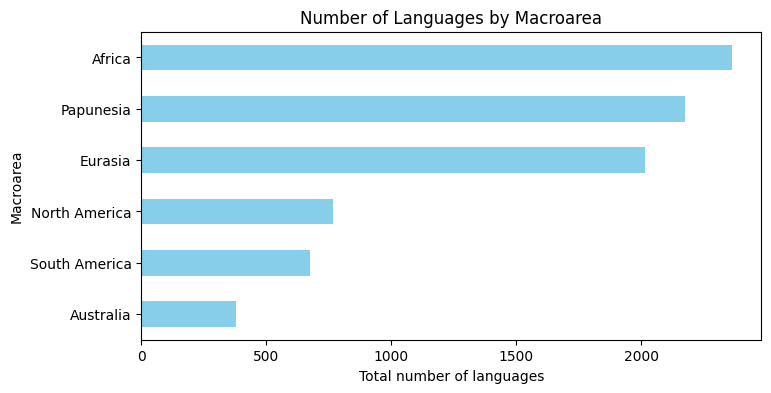

In [51]:
language_by_region.sort_values('number_of_languages').plot(
    x='macroarea',
    y='number_of_languages',
    kind='barh',
    figsize=(8,4),
    color='skyblue',
    legend=False,
    title='Number of Languages by Macroarea'
)

plt.xlabel('Total number of languages')
plt.ylabel('Macroarea')
plt.show()


In this plot, the y-axis is split into six macroareas: Africa, Papunesia, Eurasia, North America, South America, and Australia. **Africa, Papunesia, and Eurasia** have the most number of languages spoken, with at least 2000 languages. There is a big gap between the three remaining countries, which have less than 800 languages spoken.

##### Here is the same data in a pie chart:

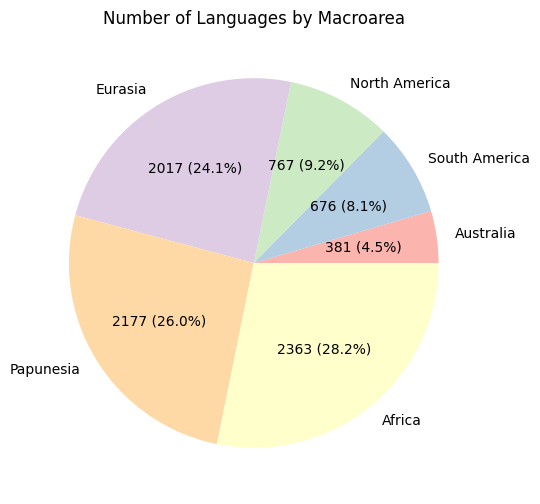

In [17]:
language_by_region.sort_values('number_of_languages').plot(
    kind='pie',
    y='number_of_languages',
    labels=language_by_region.sort_values('number_of_languages')['macroarea'],
    autopct=lambda pct: f'{pct/100.*language_by_region["number_of_languages"].sum():.0f} ({pct:.1f}%)',
    figsize=(6,6),
    colors=plt.cm.Pastel1.colors,
    legend=False,
    title='Number of Languages by Macroarea'
)

plt.ylabel('')
plt.show()

## Top Countries in Papunesia

Next, I was interested in the Papunesian region because it is definitely less heard of, but still has a significant number of languages.

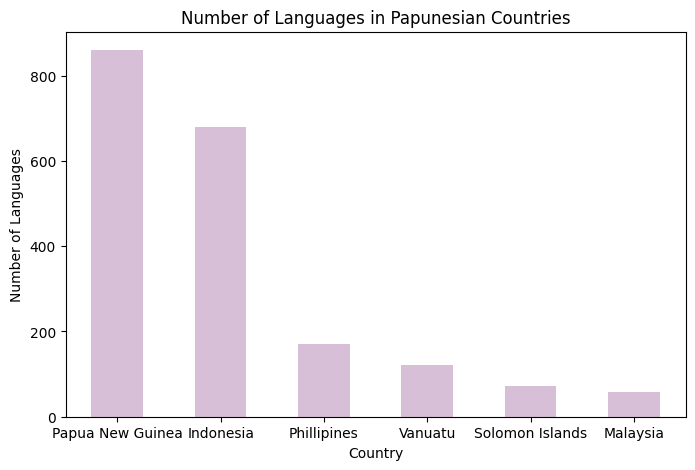

In [19]:
top6 = pap.head(6).copy()

top6['countries'] = top6['countries'].replace({
    'PG': 'Papua New Guinea',
    'ID': 'Indonesia',
    'PH': 'Phillipines',
    'VU': 'Vanuatu',
    'SB': 'Solomon Islands',
    'MY': 'Malaysia'
})

top6.plot(
    x='countries',
    y='number_of_countries',
    kind='bar',
    color='thistle',
    figsize=(8,5),
    legend=False,
    title='Number of Languages in Papunesian Countries'
)

plt.xlabel('Country')
plt.xticks(rotation=0) 
plt.ylabel('Number of Languages')
plt.show()


Unexpectedly, Papua New Guinea has more than 850 langauges spoken in the country. After I did some research, I realized that this was because of its isolating geography such as jungles and mountains that cause communities to be separated from each other. This results in unique language to form. In second place is Indonesia, which also speaks a large amount of languages for a similar reason.

## Number of Isolates by Macroarea

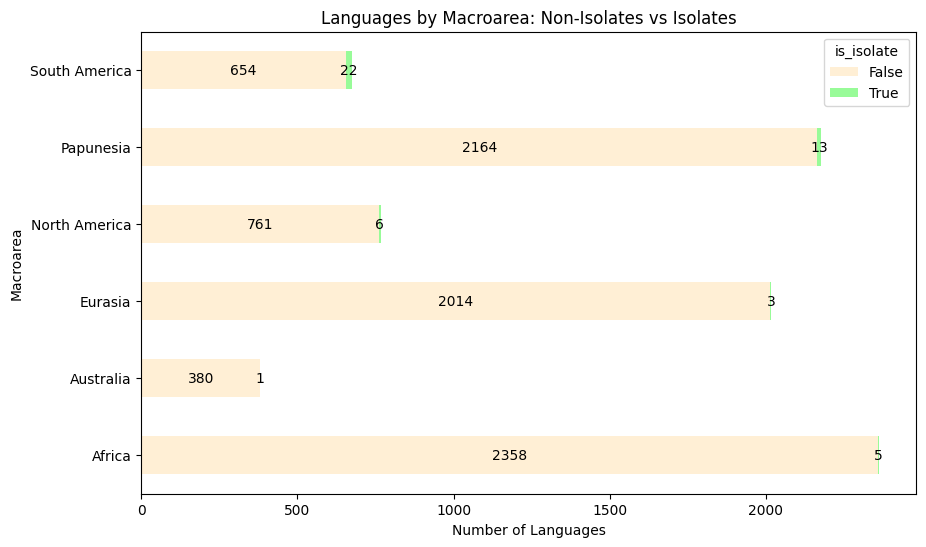

In [26]:
ax = language_pivot.plot(
    kind='barh',
    stacked=True,
    figsize=(10,6),
    color=['papayawhip', 'palegreen'],
    title='Languages by Macroarea: Non-Isolates vs Isolates'
)

plt.xlabel('Number of Languages')
plt.ylabel('Macroarea')

for container in ax.containers:
    ax.bar_label(container, label_type='center', fontsize=10)

plt.show()

An isolate language means that the language does not belong to another language family and is not related to any other language. For example, Romance languages which include Spanish, French, and Italian are NOT considered isolate languages due to being in the same family. Languages such as Basque and Ainu are considered isolate languages as they do not have a related language.

We can see that in this graph, **South America** has the highest number of isolate languages (22), which is even more impressive due to its smaller amount of total languages. Eurasia and Africa have a lower number of isolate languages despite its high number of total languages. North America has six solid isolate languages and Australia only has one isolate language.

## Reflection

Overall, I learned that Africa, Papunesia, and Eurasia had the most spoken langauges in the world. Papunesia was particularly unexpected, so I looked further into it and found out that Papua New Guinea and Indonesia have more than 600-800 languages spoken due to its unique geography. Lastly, I learned that language isolates are extremely uncommon, with South America only having 22. When it comes to visualizing the data, I wanted to do some more different plots other than bar charts, but it was hard because there was not enough numerical data to do other data plots. However, I was able to do some new visualization techniques, such as experimenting with different colors and did a pie chart for the first time.